### Weights & Biases Setup
This section installs the `wandb` library and logs into your Weights & Biases account. It attempts a non-interactive login using the `WANDB_API_KEY` stored in Colab secrets. If the key is not found, it will attempt an interactive login.

In [1]:
# Install wandb library
!pip install wandb -qqq

# import colab user data
from google.colab import userdata
import wandb

# Log in to wandb non-interactively using the API key from Colab secrets
wandb_api_key = userdata.get('WANDB_API_KEY')
if wandb_api_key:
  print("WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.")
  wandb.login(key=wandb_api_key)
else:
  print("WANDB_API_KEY not found in environment variables. Attempting interactive login.")
  print("Please ensure your W&B API key is set as a secret named 'WANDB_API_KEY' in Colab or your environment.")
  wandb.login()

WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gbera23 (gbera23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### GitHub Repository Cloning
This section clones the specified GitHub repository. It attempts to use a GitHub Personal Access Token (`GITHUB_TOKEN`) stored in Colab secrets for private repositories. If no token is found, it will attempt to clone the repository directly, which will only succeed for public repositories or if credentials are otherwise configured.

In [2]:
import os

# GitHub repository cloning
# If the repository is private, a Personal Access Token (PAT) is required.
# Assuming 'github' (which is the GITHUB_TOKEN) is available as a secret.
github_token = userdata.get('github')
repo_url = "https://github.com/gbera23-dev/Machine-Learning.git"

if github_token:
  print("GITHUB_TOKEN found. Attempting to clone GitHub repository using token.")
  # Embed the token in the URL for cloning private repos
  !git clone https://{github_token}@github.com/gbera23-dev/Machine-Learning.git
else:
  print("GITHUB_TOKEN not found in environment variables. Attempting to clone repository without explicit token.")
  print("If the repository is private, please ensure your GitHub Personal Access Token is set as a secret named 'github' in Colab or your environment.")
  !git clone {repo_url}

# Verify the repository was cloned
if os.path.exists("Machine-Learning"):
    print("Repository 'Machine-Learning' cloned successfully.")
else:
    print("Failed to clone repository 'Machine-Learning'. Please check your GitHub token if it's a private repo.")

GITHUB_TOKEN found. Attempting to clone GitHub repository using token.
fatal: destination path 'Machine-Learning' already exists and is not an empty directory.
Repository 'Machine-Learning' cloned successfully.


In [3]:
# Install the Kaggle API client
!pip install kaggle -qqq

### Kaggle authorization

In [4]:
%cd Machine-Learning/Assignment4

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


%ls

/content/Machine-Learning/Assignment4
mv: cannot stat 'kaggle.json': No such file or directory
challenges-in-representation-learning-facial-expression-recognition-challenge_data/
challenges-in-representation-learning-facial-expression-recognition-challenge.zip
model_files/
pipeline_v_lr0.0001_bs128.pth
pipeline_v_lr0.0001_bs32.pth
pipeline_v_lr0.0005_bs128.pth
pipeline_v_lr0.0005_bs32.pth
pipeline_v_lr0.001_bs128.pth
pipeline_v_lr0.001_bs32.pth
pipeline_v_lr0.005_bs128.pth
pipeline_v_lr0.005_bs32.pth
pipeline_v_lr0.01_bs128.pth
pipeline_v_lr0.01_bs32.pth
README.md
wandb/


### Download Kaggle Competition Data

Now, we can download the data for the 'Challenges in Representation Learning, Facial Expression Recognition Challenge' competition. The competition name on Kaggle is `challenges-in-representation-learning-facial-expression-recognition-challenge`.

In [5]:
# Define the competition name
competition_name = 'challenges-in-representation-learning-facial-expression-recognition-challenge'

# Download the competition data
!kaggle competitions download -c {competition_name}

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


### Unzip the Downloaded Data

In [ ]:
zip_file_name = f"{competition_name}.zip"

!unzip -q {zip_file_name} -d "./{competition_name}_data"

!ls -F "./{competition_name}_data"

print(f"Data unzipped to ./{competition_name}_data")

### Change directory to Machine-Learning

In [ ]:
# %cd Machine-Learning

## 1. Exploratory Data Analysis (EDA)
We will load the dataset and visualize the classes to understand the distribution of emotions.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the data
data_path = './challenges-in-representation-learning-facial-expression-recognition-challenge_data/icml_face_data.csv'
df = pd.read_csv(data_path)

# Display basic info
print(f"Dataset Shape: {df.shape}")
display(df.head())

# Check the usage split (Training, PublicTest, PrivateTest)
print("\nUsage distribution:")
print(df[' Usage'].value_counts())

Dataset Shape: (35887, 3)


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Usage distribution:
 Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


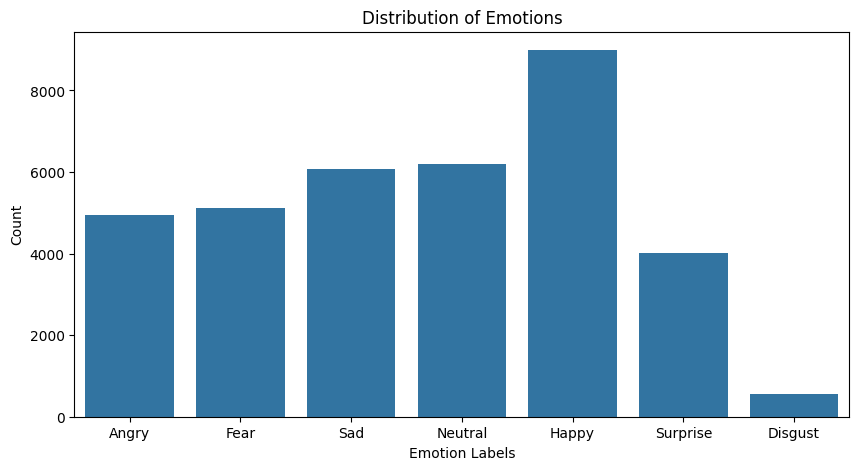

In [7]:
# Emotion mapping
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Visualize Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df['emotion'].map(emotion_map))
plt.title('Distribution of Emotions')
plt.xlabel('Emotion Labels')
plt.ylabel('Count')
plt.show()

Sample images from the dataset:


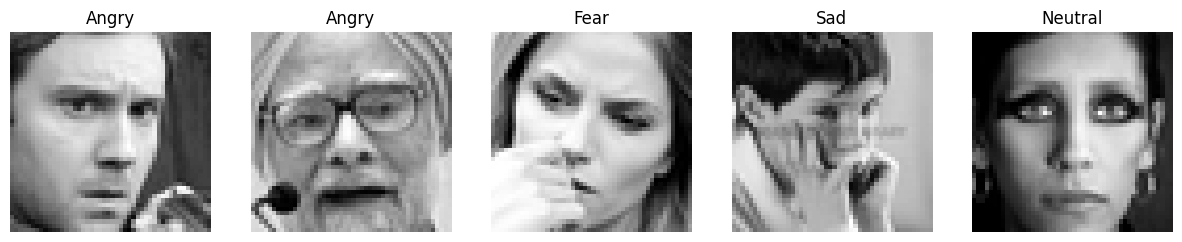

In [8]:
def plot_samples(df, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):

        pixels = df.iloc[i][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(emotion_map[df.iloc[i]['emotion']])
        plt.axis('off')
    plt.show()

print("Sample images from the dataset:")
plot_samples(df)

### 1.2 Deep Dive into Data Structure
Let's look at the raw training data structure and the distribution of pixel intensities across all images.

Raw Pixel Data Example (First 50 characters of the first row):
70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119...


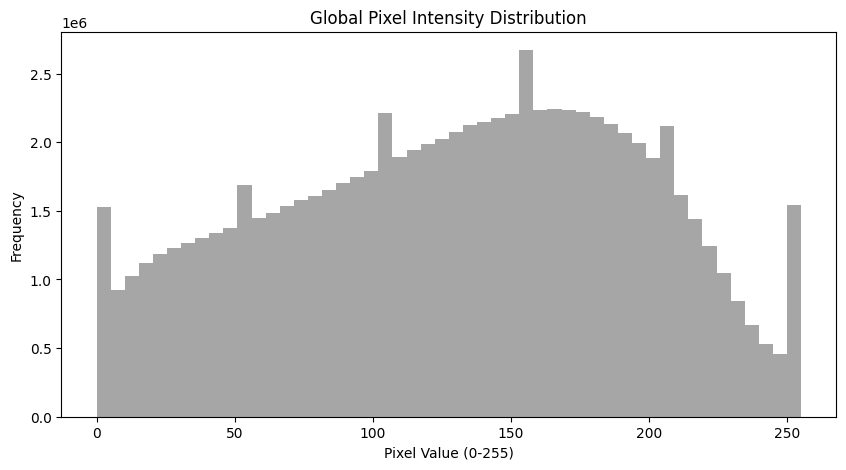

In [9]:
print("Raw Pixel Data Example (First 50 characters of the first row):")
print(df.loc[0, ' pixels'][:50] + "...")

all_pixels = np.array([np.fromstring(x, dtype=int, sep=' ') for x in df[' pixels']])

plt.figure(figsize=(10, 5))
plt.hist(all_pixels.flatten(), bins=50, color='gray', alpha=0.7)

plt.title('Global Pixel Intensity Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.show()

## 2. Data Preparation
We will create a custom PyTorch Dataset to handle the conversion of pixel strings to tensors and apply basic normalization.

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Extract pixels and label
        pixels = self.df.iloc[idx][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)
        label = int(self.df.iloc[idx]['emotion'])

        # Add channel dimension (H, W) -> (H, W, C) for transforms
        image = image[:, :, np.newaxis] / 255.0

        if self.transform:
            image = self.transform(image)

        return image, label

# Define basic transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    # Note: We can add augmentation here later
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Split the dataframe based on ' Usage'
train_df = df[df[' Usage'] == 'Training']
val_df = df[df[' Usage'] == 'PublicTest']

# Initialize Datasets
train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_transform)

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"DataLoaders created with {len(train_dataset)} training and {len(val_dataset)} validation samples.")

DataLoaders created with 28709 training and 3589 validation samples.


## 3. Model Development
### 3.2 Iteration 2: Deep CNN with Batch Normalization
This model is deeper than the baseline and includes Batch Normalization layers to improve convergence speed and stability.

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class DeepCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(DeepCNN, self).__init__()
        # Block 1: 48x48 -> 24x24
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 2: 24x24 -> 12x12
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 3: 12x12 -> 6x6
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepCNN(num_classes=7).to(device)
print(f"DeepCNN initialized on device: {device}")

DeepCNN initialized on device: cuda


### 3.2 Define Loss Function and Optimizer
We will use CrossEntropyLoss (standard for classification) and the Adam optimizer.

In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


### 3.4 Training Loop
We iterate through the training data, update the model weights, and log metrics to W&B.

Create sweep with ID: i1ktfmnv
Sweep URL: https://wandb.ai/gbera23-free-university-of-tbilisi-/facial-expression-recognition/sweeps/i1ktfmnv


wandb: Agent Starting Run: 4l9c6rga with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


DeepRun: breezy-sweep-1 | Epoch 1, Loss: 1.8245
DeepRun: breezy-sweep-1 | Epoch 2, Loss: 1.5982
DeepRun: breezy-sweep-1 | Epoch 3, Loss: 1.5242
DeepRun: breezy-sweep-1 | Epoch 4, Loss: 1.4697
DeepRun: breezy-sweep-1 | Epoch 5, Loss: 1.4367


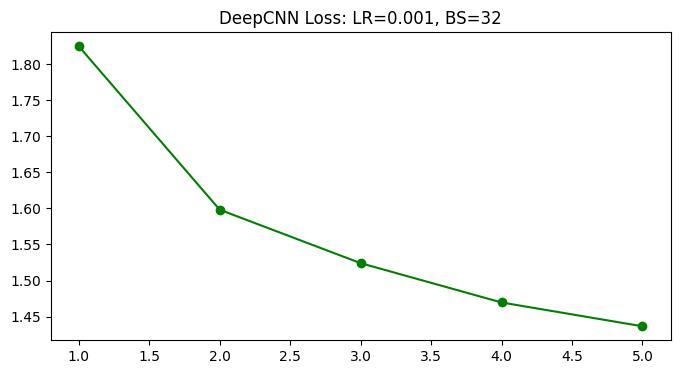

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


deep_train_loss,█▄▃▂▁
epoch,▁▃▅▆█
deep_train_loss,1.43675
epoch,5


wandb: Agent Starting Run: y3v43vkq with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


DeepRun: iconic-sweep-2 | Epoch 1, Loss: 1.6885
DeepRun: iconic-sweep-2 | Epoch 2, Loss: 1.4883
DeepRun: iconic-sweep-2 | Epoch 3, Loss: 1.4006
DeepRun: iconic-sweep-2 | Epoch 4, Loss: 1.3386
DeepRun: iconic-sweep-2 | Epoch 5, Loss: 1.2849


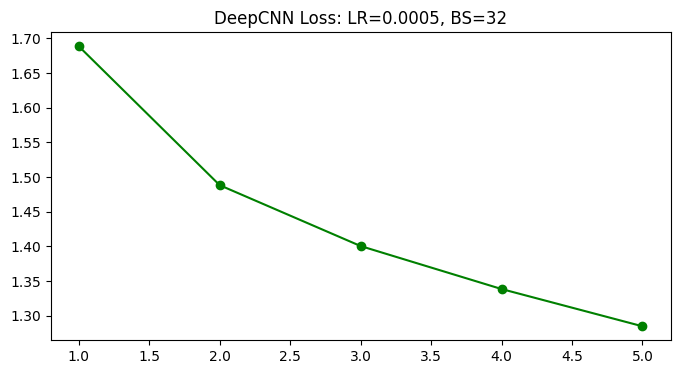

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


deep_train_loss,█▅▃▂▁
epoch,▁▃▅▆█
deep_train_loss,1.28494
epoch,5


wandb: Agent Starting Run: u8p1niij with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


DeepRun: resilient-sweep-3 | Epoch 1, Loss: 1.6139
DeepRun: resilient-sweep-3 | Epoch 2, Loss: 1.4077
DeepRun: resilient-sweep-3 | Epoch 3, Loss: 1.3185
DeepRun: resilient-sweep-3 | Epoch 4, Loss: 1.2528
DeepRun: resilient-sweep-3 | Epoch 5, Loss: 1.1952


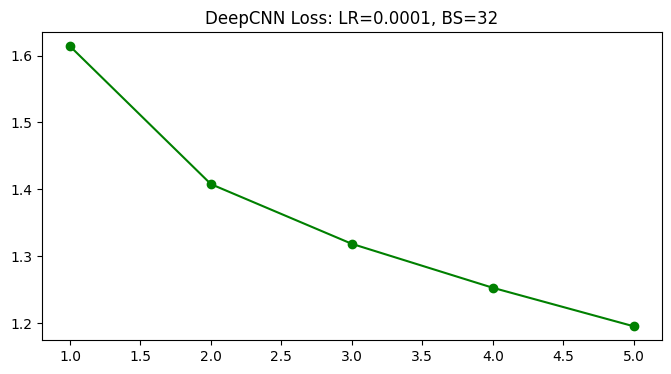

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


deep_train_loss,█▅▃▂▁
epoch,▁▃▅▆█
deep_train_loss,1.19516
epoch,5


wandb: Agent Starting Run: 4oxdo2ye with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


DeepRun: autumn-sweep-4 | Epoch 1, Loss: 1.8872
DeepRun: autumn-sweep-4 | Epoch 2, Loss: 1.5846
DeepRun: autumn-sweep-4 | Epoch 3, Loss: 1.4865
DeepRun: autumn-sweep-4 | Epoch 4, Loss: 1.4196
DeepRun: autumn-sweep-4 | Epoch 5, Loss: 1.3731


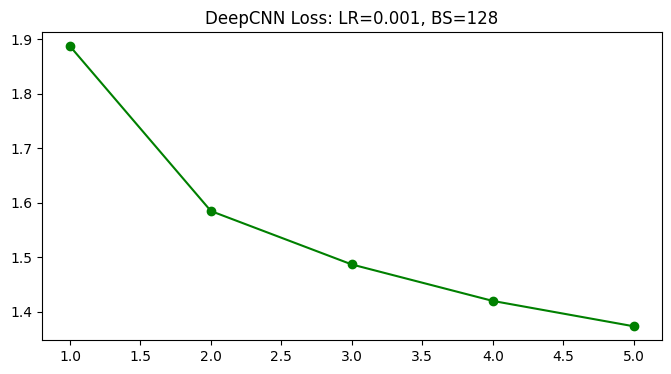

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


deep_train_loss,█▄▃▂▁
epoch,▁▃▅▆█
deep_train_loss,1.37306
epoch,5


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: hopiq42b with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


DeepRun: smart-sweep-5 | Epoch 1, Loss: 1.8526
DeepRun: smart-sweep-5 | Epoch 2, Loss: 1.5392
DeepRun: smart-sweep-5 | Epoch 3, Loss: 1.4247
DeepRun: smart-sweep-5 | Epoch 4, Loss: 1.3573
DeepRun: smart-sweep-5 | Epoch 5, Loss: 1.3053


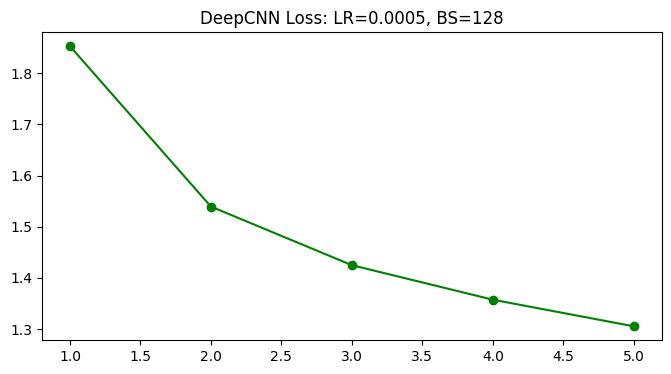

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


deep_train_loss,█▄▃▂▁
epoch,▁▃▅▆█
deep_train_loss,1.30527
epoch,5


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 43q3u6j2 with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


DeepRun: smooth-sweep-6 | Epoch 1, Loss: 1.6282
DeepRun: smooth-sweep-6 | Epoch 2, Loss: 1.4265
DeepRun: smooth-sweep-6 | Epoch 3, Loss: 1.3256
DeepRun: smooth-sweep-6 | Epoch 4, Loss: 1.2612
DeepRun: smooth-sweep-6 | Epoch 5, Loss: 1.2070


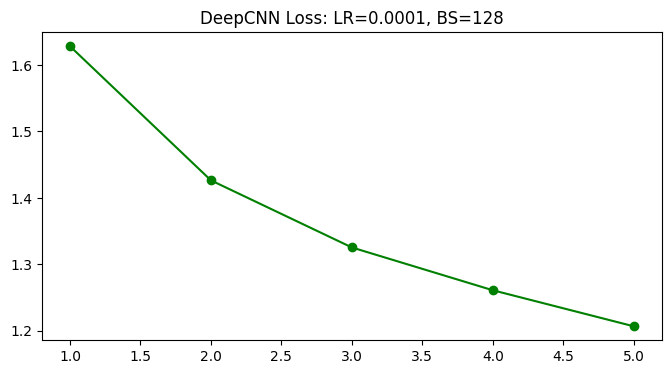

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


deep_train_loss,█▅▃▂▁
epoch,▁▃▅▆█
deep_train_loss,1.20702
epoch,5


In [13]:
import matplotlib.pyplot as plt
import wandb
import torch
import torch.nn as nn

class FERPipeline(nn.Module):
    def __init__(self, model, transform):
        super(FERPipeline, self).__init__()
        self.model = model
        self.transform = transform

    def forward(self, x):
        return self.model(x)

def train_sweep():
    with wandb.init() as run:
        config = run.config
        # Initialize DeepCNN
        sweep_model = DeepCNN(num_classes=7).to(device)
        sweep_optimizer = optim.Adam(sweep_model.parameters(), lr=config.learning_rate)
        sweep_train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
        current_pipeline = FERPipeline(sweep_model, val_transform)

        loss_history = []
        num_epochs = 5

        for epoch in range(num_epochs):
            sweep_model.train()
            running_loss = 0.0
            for images, labels in sweep_train_loader:
                images, labels = images.to(device), labels.to(device)
                sweep_optimizer.zero_grad()
                loss = criterion(sweep_model(images), labels)
                loss.backward()
                sweep_optimizer.step()
                running_loss += loss.item()

            avg_loss = running_loss / len(sweep_train_loader)
            loss_history.append(avg_loss)
            wandb.log({"epoch": epoch + 1, "deep_train_loss": avg_loss})
            print(f"DeepRun: {run.name} | Epoch {epoch+1}, Loss: {avg_loss:.4f}")

        # Local Visualization
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, num_epochs + 1), loss_history, marker='o', color='green')
        plt.title(f"DeepCNN Loss: LR={config.learning_rate}, BS={config.batch_size}")
        plt.show()

        # Log Pipeline
        model_filename = f"deep_pipeline_lr{config.learning_rate}_bs{config.batch_size}.pth"
        torch.save(current_pipeline.state_dict(), model_filename)
        wandb.save(model_filename)

# New sweep config for iteration 2
sweep_config = {
    'method': 'grid',
    'parameters': {
        'learning_rate': {"values": [0.001, 0.0005, 0.0001]},
        'batch_size': {"values": [32, 128]}
    }
}

sweep_id = wandb.sweep(sweep_config, project="facial-expression-recognition")
wandb.agent(sweep_id, function=train_sweep, count=6)